In [2]:
import sys
import pyodbc

print("Python executable:")
print(sys.executable)

print("\npyodbc version:")
print(pyodbc.version)

print("\nODBC drivers:")
print(pyodbc.drivers())

Python executable:
c:\Data Analytics\Automated Commercial Performance Reporting System\.venv\Scripts\python.exe

pyodbc version:
5.3.0

ODBC drivers:
['SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)', 'ODBC Driver 18 for SQL Server', 'ODBC Driver 17 for SQL Server']


In [3]:
print("Notebook kernel test")

Notebook kernel test


In [4]:
print("Notebook kernel test")

Notebook kernel test


In [5]:
import sys

print(sys.executable)

c:\Data Analytics\Automated Commercial Performance Reporting System\.venv\Scripts\python.exe


In [6]:
print("Fresh kernel test")

Fresh kernel test


In [7]:
import sys
print(sys.executable)

c:\Data Analytics\Automated Commercial Performance Reporting System\.venv\Scripts\python.exe


In [8]:
import pyodbc
print(pyodbc.version)

5.3.0


In [9]:
import pyodbc

connection_string = (
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost\\SQLEXPRESS;"
    "DATABASE=AdventureWorks2022;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

connection = pyodbc.connect(
    connection_string,
    timeout=5
)

print("Connection successful.")

Connection successful.


In [10]:
cursor = connection.cursor()

cursor.execute("""
    SELECT
        @@SERVERNAME AS ServerName,
        DB_NAME() AS DatabaseName;
""")

row = cursor.fetchone()

print("Server:", row.ServerName)
print("Database:", row.DatabaseName)

Server: ROKKA\SQLEXPRESS
Database: AdventureWorks2022


In [11]:
cursor = connection.cursor()

cursor.execute("""
    SELECT COUNT(*) AS SalesOrderDetailRows
    FROM Sales.SalesOrderDetail;
""")

row = cursor.fetchone()

print("SalesOrderDetail rows:", row.SalesOrderDetailRows)

SalesOrderDetail rows: 121317


In [12]:
import pandas as pd

sales_detail_df = pd.read_sql_query(
    """
    SELECT
        SalesOrderID,
        SalesOrderDetailID,
        CarrierTrackingNumber,
        OrderQty,
        ProductID,
        SpecialOfferID,
        UnitPrice,
        UnitPriceDiscount,
        LineTotal,
        rowguid,
        ModifiedDate
    FROM Sales.SalesOrderDetail;
    """,
    connection
)

print("Rows:", len(sales_detail_df))
print("Columns:", len(sales_detail_df.columns))

C:\Users\aoket\AppData\Local\Temp\ipykernel_28360\3967245697.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_detail_df = pd.read_sql_query(


Rows: 121317
Columns: 11


In [13]:
sales_detail_df.head()

,SalesOrderID,SalesOrderDetailID,CarrierTrackingNumber,OrderQty,ProductID,SpecialOfferID,UnitPrice,UnitPriceDiscount,LineTotal,rowguid,ModifiedDate
0,43659,1,4911-403C-98,1,776,1,2024.994,0.0,2024.994,B207C96D-D9E6-402B-8470-2CC176C42283,2011-05-31
1,43659,2,4911-403C-98,3,777,1,2024.994,0.0,6074.982,7ABB600D-1E77-41BE-9FE5-B9142CFC08FA,2011-05-31
2,43659,3,4911-403C-98,1,778,1,2024.994,0.0,2024.994,475CF8C6-49F6-486E-B0AD-AFC6A50CDD2F,2011-05-31
3,43659,4,4911-403C-98,1,771,1,2039.994,0.0,2039.994,04C4DE91-5815-45D6-8670-F462719FBCE3,2011-05-31
4,43659,5,4911-403C-98,1,772,1,2039.994,0.0,2039.994,5A74C7D2-E641-438E-A7AC-37BF23280301,2011-05-31


In [14]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

connection_string = quote_plus(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost\\SQLEXPRESS;"
    "DATABASE=AdventureWorks2022;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={connection_string}"
)

print("SQLAlchemy engine created successfully.")

SQLAlchemy engine created successfully.


In [15]:
from sqlalchemy import text

with engine.connect() as conn:
    result = conn.execute(
        text("""
            SELECT
                @@SERVERNAME AS ServerName,
                DB_NAME() AS DatabaseName;
        """)
    )

    row = result.fetchone()

print("Server:", row.ServerName)
print("Database:", row.DatabaseName)

Server: ROKKA\SQLEXPRESS
Database: AdventureWorks2022


In [16]:
sales_detail_df = pd.read_sql_query(
    """
    SELECT
        SalesOrderID,
        SalesOrderDetailID,
        CarrierTrackingNumber,
        OrderQty,
        ProductID,
        SpecialOfferID,
        UnitPrice,
        UnitPriceDiscount,
        LineTotal,
        rowguid,
        ModifiedDate
    FROM Sales.SalesOrderDetail;
    """,
    engine
)

print("Rows:", len(sales_detail_df))
print("Columns:", len(sales_detail_df.columns))

Rows: 121317
Columns: 11


In [17]:
source_row_count = 121317
python_row_count = len(sales_detail_df)

difference = source_row_count - python_row_count

print("Source rows:       ", source_row_count)
print("Python rows:       ", python_row_count)
print("Difference:        ", difference)
print("Reconciliation:    ", "PASS" if difference == 0 else "FAIL")

Source rows:        121317
Python rows:        121317
Difference:         0
Reconciliation:     PASS


In [18]:
print("Shape:", sales_detail_df.shape)

print("\nColumns:")
for column in sales_detail_df.columns:
    print("-", column)

Shape: (121317, 11)

Columns:
- SalesOrderID
- SalesOrderDetailID
- CarrierTrackingNumber
- OrderQty
- ProductID
- SpecialOfferID
- UnitPrice
- UnitPriceDiscount
- LineTotal
- rowguid
- ModifiedDate


In [19]:
sales_detail_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 121317 entries, 0 to 121316
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   SalesOrderID           121317 non-null  int64         
 1   SalesOrderDetailID     121317 non-null  int64         
 2   CarrierTrackingNumber  60919 non-null   str           
 3   OrderQty               121317 non-null  int64         
 4   ProductID              121317 non-null  int64         
 5   SpecialOfferID         121317 non-null  int64         
 6   UnitPrice              121317 non-null  float64       
 7   UnitPriceDiscount      121317 non-null  float64       
 8   LineTotal              121317 non-null  float64       
 9   rowguid                121317 non-null  str           
 10  ModifiedDate           121317 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(3), int64(5), str(2)
memory usage: 10.2 MB


In [20]:
duplicate_detail_ids = sales_detail_df[
    sales_detail_df["SalesOrderDetailID"].duplicated(keep=False)
]

print("Duplicate SalesOrderDetailID rows:", len(duplicate_detail_ids))

Duplicate SalesOrderDetailID rows: 0


In [21]:
unique_detail_ids = sales_detail_df["SalesOrderDetailID"].nunique()

print("Total rows:", len(sales_detail_df))
print("Unique SalesOrderDetailID:", unique_detail_ids)
print(
    "Grain validation:",
    "PASS" if len(sales_detail_df) == unique_detail_ids else "FAIL"
)

Total rows: 121317
Unique SalesOrderDetailID: 121317
Grain validation: PASS


In [22]:
from sqlalchemy import text

with engine.connect() as conn:
    result = conn.execute(
        text("""
            SELECT
                COUNT(*) AS SalesRowCount,
                SUM(CAST(LineTotal AS decimal(19,6))) AS TotalRevenue
            FROM Sales.SalesOrderDetail;
        """)
    )

    row = result.fetchone()

print("SQL Server rows:", row.SalesRowCount)
print("SQL Server revenue:", row.TotalRevenue)

SQL Server rows: 121317
SQL Server revenue: 109846381.399888


In [23]:
python_row_count = len(sales_detail_df)
python_revenue = sales_detail_df["LineTotal"].sum()

print("Python rows:", python_row_count)
print("Python revenue:", python_revenue)

Python rows: 121317
Python revenue: 109846381.39988798


In [24]:
revenue_difference = float(row.TotalRevenue) - python_revenue

print("Revenue difference:", revenue_difference)

print(
    "Financial reconciliation:",
    "PASS" if abs(revenue_difference) < 0.01 else "FAIL"
)

Revenue difference: 1.4901161193847656e-08
Financial reconciliation: PASS


In [25]:
key_columns = [
    "SalesOrderID",
    "SalesOrderDetailID",
    "ProductID",
    "SpecialOfferID"
]

key_nulls = sales_detail_df[key_columns].isna().sum()

print("Null counts for required keys:")
print(key_nulls)

print("\nKey validation:")
print(
    "PASS"
    if key_nulls.sum() == 0
    else "FAIL"
)

Null counts for required keys:
SalesOrderID          0
SalesOrderDetailID    0
ProductID             0
SpecialOfferID        0
dtype: int64

Key validation:
PASS


In [26]:
with engine.connect() as conn:
    result = conn.execute(
        text("""
            SELECT COUNT(DISTINCT sod.ProductID)
            FROM Sales.SalesOrderDetail AS sod;
        """)
    )

    source_product_count = result.scalar()

python_product_count = sales_detail_df["ProductID"].nunique()

print("Distinct ProductIDs in SQL Server:", source_product_count)
print("Distinct ProductIDs in Python:", python_product_count)
print(
    "Product population reconciliation:",
    "PASS"
    if source_product_count == python_product_count
    else "FAIL"
)

Distinct ProductIDs in SQL Server: 266
Distinct ProductIDs in Python: 266
Product population reconciliation: PASS


In [27]:
with engine.connect() as conn:
    result = conn.execute(
        text("""
            SELECT COUNT(*)
            FROM (
                SELECT DISTINCT ProductID
                FROM Sales.SalesOrderDetail
            ) AS sales_products
            LEFT JOIN Production.Product AS p
                ON sales_products.ProductID = p.ProductID
            WHERE p.ProductID IS NULL;
        """)
    )

    orphan_product_count = result.scalar()

print("Orphan ProductIDs:", orphan_product_count)
print(
    "Product relationship validation:",
    "PASS"
    if orphan_product_count == 0
    else "FAIL"
)

Orphan ProductIDs: 0
Product relationship validation: PASS


In [28]:
with engine.connect() as conn:
    result = conn.execute(
        text("""
            SELECT COUNT(*)
            FROM (
                SELECT DISTINCT SalesOrderID
                FROM Sales.SalesOrderDetail
            ) AS detail_orders
            LEFT JOIN Sales.SalesOrderHeader AS soh
                ON detail_orders.SalesOrderID = soh.SalesOrderID
            WHERE soh.SalesOrderID IS NULL;
        """)
    )

    orphan_order_count = result.scalar()

print("Orphan SalesOrderIDs:", orphan_order_count)

print(
    "Sales order relationship validation:",
    "PASS"
    if orphan_order_count == 0
    else "FAIL"
)

Orphan SalesOrderIDs: 0
Sales order relationship validation: PASS


In [29]:
with engine.connect() as conn:
    result = conn.execute(
        text("""
            SELECT COUNT(*)
            FROM (
                SELECT DISTINCT CustomerID
                FROM Sales.SalesOrderHeader
            ) AS order_customers
            LEFT JOIN Sales.Customer AS c
                ON order_customers.CustomerID = c.CustomerID
            WHERE c.CustomerID IS NULL;
        """)
    )

    orphan_customer_count = result.scalar()

print("Orphan CustomerIDs:", orphan_customer_count)

print(
    "Customer relationship validation:",
    "PASS"
    if orphan_customer_count == 0
    else "FAIL"
)

Orphan CustomerIDs: 0
Customer relationship validation: PASS


In [30]:
with engine.connect() as conn:
    result = conn.execute(
        text("""
            SELECT COUNT(*)
            FROM Sales.Customer AS c
            LEFT JOIN Person.Person AS p
                ON c.PersonID = p.BusinessEntityID
            WHERE c.PersonID IS NOT NULL
              AND p.BusinessEntityID IS NULL;
        """)
    )

    orphan_person_count = result.scalar()

print("Orphan Customer PersonIDs:", orphan_person_count)

print(
    "Customer → Person validation:",
    "PASS"
    if orphan_person_count == 0
    else "FAIL"
)

Orphan Customer PersonIDs: 0
Customer → Person validation: PASS


In [31]:
with engine.connect() as conn:
    result = conn.execute(
        text("""
            SELECT COUNT(*)
            FROM (
                SELECT DISTINCT SalesPersonID
                FROM Sales.SalesOrderHeader
                WHERE SalesPersonID IS NOT NULL
            ) AS order_salespeople
            LEFT JOIN Sales.SalesPerson AS sp
                ON order_salespeople.SalesPersonID = sp.BusinessEntityID
            WHERE sp.BusinessEntityID IS NULL;
        """)
    )

    orphan_salesperson_count = result.scalar()

print("Orphan SalesPersonIDs:", orphan_salesperson_count)

print(
    "Salesperson relationship validation:",
    "PASS"
    if orphan_salesperson_count == 0
    else "FAIL"
)

Orphan SalesPersonIDs: 0
Salesperson relationship validation: PASS


In [32]:
with engine.connect() as conn:
    result = conn.execute(
        text("""
            SELECT COUNT(*)
            FROM Sales.SalesPerson AS sp
            LEFT JOIN HumanResources.Employee AS e
                ON sp.BusinessEntityID = e.BusinessEntityID
            WHERE e.BusinessEntityID IS NULL;
        """)
    )

    orphan_employee_count = result.scalar()

print("Orphan SalesPerson Employee IDs:", orphan_employee_count)

print(
    "Salesperson → Employee validation:",
    "PASS"
    if orphan_employee_count == 0
    else "FAIL"
)

Orphan SalesPerson Employee IDs: 0
Salesperson → Employee validation: PASS


In [33]:
with engine.connect() as conn:
    result = conn.execute(
        text("""
            SELECT COUNT(*)
            FROM Sales.SalesPerson AS sp
            LEFT JOIN Person.Person AS p
                ON sp.BusinessEntityID = p.BusinessEntityID
            WHERE p.BusinessEntityID IS NULL;
        """)
    )

    orphan_salesperson_person_count = result.scalar()

print(
    "Orphan SalesPerson Person IDs:",
    orphan_salesperson_person_count
)

print(
    "Salesperson → Person validation:",
    "PASS"
    if orphan_salesperson_person_count == 0
    else "FAIL"
)

Orphan SalesPerson Person IDs: 0
Salesperson → Person validation: PASS


In [34]:
sales_reporting_df = pd.read_sql_query(
    """
    SELECT
        soh.SalesOrderID,
        sod.SalesOrderDetailID,
        soh.OrderDate,
        soh.CustomerID,
        soh.SalesPersonID,
        soh.TerritoryID,
        sod.ProductID,
        sod.OrderQty,
        sod.UnitPrice,
        sod.UnitPriceDiscount,
        sod.LineTotal
    FROM Sales.SalesOrderHeader AS soh
    INNER JOIN Sales.SalesOrderDetail AS sod
        ON soh.SalesOrderID = sod.SalesOrderID;
    """,
    engine
)

print("Rows:", len(sales_reporting_df))
print("Columns:", len(sales_reporting_df.columns))

Rows: 121317
Columns: 11


In [35]:
sales_reporting_df = pd.read_sql_query(
    """
    SELECT
        soh.SalesOrderID,
        sod.SalesOrderDetailID,
        soh.OrderDate,
        soh.CustomerID,
        soh.SalesPersonID,
        soh.TerritoryID,
        sod.ProductID,
        p.Name AS ProductName,
        ps.Name AS ProductSubcategory,
        pc.Name AS ProductCategory,
        sod.OrderQty,
        sod.UnitPrice,
        sod.UnitPriceDiscount,
        sod.LineTotal
    FROM Sales.SalesOrderHeader AS soh
    INNER JOIN Sales.SalesOrderDetail AS sod
        ON soh.SalesOrderID = sod.SalesOrderID
    INNER JOIN Production.Product AS p
        ON sod.ProductID = p.ProductID
    LEFT JOIN Production.ProductSubcategory AS ps
        ON p.ProductSubcategoryID = ps.ProductSubcategoryID
    LEFT JOIN Production.ProductCategory AS pc
        ON ps.ProductCategoryID = pc.ProductCategoryID;
    """,
    engine
)

print("Rows:", len(sales_reporting_df))
print("Columns:", len(sales_reporting_df.columns))

Rows: 121317
Columns: 14


In [36]:
sales_reporting_df.head()

,SalesOrderID,SalesOrderDetailID,OrderDate,CustomerID,SalesPersonID,TerritoryID,ProductID,ProductName,ProductSubcategory,ProductCategory,OrderQty,UnitPrice,UnitPriceDiscount,LineTotal
0,43659,1,2011-05-31,29825,279.0,5,776,"Mountain-100 Black, 42",Mountain Bikes,Bikes,1,2024.994,0.0,2024.994
1,43659,2,2011-05-31,29825,279.0,5,777,"Mountain-100 Black, 44",Mountain Bikes,Bikes,3,2024.994,0.0,6074.982
2,43659,3,2011-05-31,29825,279.0,5,778,"Mountain-100 Black, 48",Mountain Bikes,Bikes,1,2024.994,0.0,2024.994
3,43659,4,2011-05-31,29825,279.0,5,771,"Mountain-100 Silver, 38",Mountain Bikes,Bikes,1,2039.994,0.0,2039.994
4,43659,5,2011-05-31,29825,279.0,5,772,"Mountain-100 Silver, 42",Mountain Bikes,Bikes,1,2039.994,0.0,2039.994


In [37]:
sales_reporting_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 121317 entries, 0 to 121316
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   SalesOrderID        121317 non-null  int64         
 1   SalesOrderDetailID  121317 non-null  int64         
 2   OrderDate           121317 non-null  datetime64[us]
 3   CustomerID          121317 non-null  int64         
 4   SalesPersonID       60919 non-null   float64       
 5   TerritoryID         121317 non-null  int64         
 6   ProductID           121317 non-null  int64         
 7   ProductName         121317 non-null  str           
 8   ProductSubcategory  121317 non-null  str           
 9   ProductCategory     121317 non-null  str           
 10  OrderQty            121317 non-null  int64         
 11  UnitPrice           121317 non-null  float64       
 12  UnitPriceDiscount   121317 non-null  float64       
 13  LineTotal           121317 non-null  flo

In [38]:
sales_reporting_df = pd.read_sql_query(
    """
    SELECT
        soh.SalesOrderID,
        sod.SalesOrderDetailID,
        soh.OrderDate,
        soh.CustomerID,
        c.AccountNumber,
        p.FirstName,
        p.LastName,
        soh.SalesPersonID,
        soh.TerritoryID,
        sod.ProductID,
        prod.Name AS ProductName,
        ps.Name AS ProductSubcategory,
        pc.Name AS ProductCategory,
        sod.OrderQty,
        sod.UnitPrice,
        sod.UnitPriceDiscount,
        sod.LineTotal
    FROM Sales.SalesOrderHeader AS soh
    INNER JOIN Sales.SalesOrderDetail AS sod
        ON soh.SalesOrderID = sod.SalesOrderID
    INNER JOIN Sales.Customer AS c
        ON soh.CustomerID = c.CustomerID
    LEFT JOIN Person.Person AS p
        ON c.PersonID = p.BusinessEntityID
    INNER JOIN Production.Product AS prod
        ON sod.ProductID = prod.ProductID
    LEFT JOIN Production.ProductSubcategory AS ps
        ON prod.ProductSubcategoryID = ps.ProductSubcategoryID
    LEFT JOIN Production.ProductCategory AS pc
        ON ps.ProductCategoryID = pc.ProductCategoryID;
    """,
    engine
)

print("Rows:", len(sales_reporting_df))
print("Columns:", len(sales_reporting_df.columns))

Rows: 121317
Columns: 17


In [39]:
sales_reporting_df = pd.read_sql_query(
    """
    SELECT
        soh.SalesOrderID,
        sod.SalesOrderDetailID,
        soh.OrderDate,

        soh.CustomerID,
        c.AccountNumber,
        cp.FirstName,
        cp.LastName,

        soh.SalesPersonID,
        sp.FirstName AS SalesPersonFirstName,
        sp.LastName AS SalesPersonLastName,

        soh.TerritoryID,
        st.Name AS TerritoryName,
        st.CountryRegionCode,
        st.[Group] AS TerritoryGroup,

        sod.ProductID,
        prod.Name AS ProductName,
        ps.Name AS ProductSubcategory,
        pc.Name AS ProductCategory,

        sod.OrderQty,
        sod.UnitPrice,
        sod.UnitPriceDiscount,
        sod.LineTotal

    FROM Sales.SalesOrderHeader AS soh

    INNER JOIN Sales.SalesOrderDetail AS sod
        ON soh.SalesOrderID = sod.SalesOrderID

    INNER JOIN Sales.Customer AS c
        ON soh.CustomerID = c.CustomerID

    LEFT JOIN Person.Person AS cp
        ON c.PersonID = cp.BusinessEntityID

    LEFT JOIN Sales.SalesPerson AS sp_base
        ON soh.SalesPersonID = sp_base.BusinessEntityID

    LEFT JOIN Person.Person AS sp
        ON sp_base.BusinessEntityID = sp.BusinessEntityID

    INNER JOIN Sales.SalesTerritory AS st
        ON soh.TerritoryID = st.TerritoryID

    INNER JOIN Production.Product AS prod
        ON sod.ProductID = prod.ProductID

    LEFT JOIN Production.ProductSubcategory AS ps
        ON prod.ProductSubcategoryID = ps.ProductSubcategoryID

    LEFT JOIN Production.ProductCategory AS pc
        ON ps.ProductCategoryID = pc.ProductCategoryID;
    """,
    engine
)

print("Rows:", len(sales_reporting_df))
print("Columns:", len(sales_reporting_df.columns))

Rows: 121317
Columns: 22


In [40]:
sales_cost_df = pd.read_sql_query(
    """
    SELECT
        soh.SalesOrderID,
        sod.SalesOrderDetailID,
        soh.OrderDate,

        soh.CustomerID,
        c.AccountNumber,
        cp.FirstName,
        cp.LastName,

        soh.SalesPersonID,
        sp.FirstName AS SalesPersonFirstName,
        sp.LastName AS SalesPersonLastName,

        soh.TerritoryID,
        st.Name AS TerritoryName,
        st.CountryRegionCode,
        st.[Group] AS TerritoryGroup,

        sod.ProductID,
        prod.Name AS ProductName,
        ps.Name AS ProductSubcategory,
        pc.Name AS ProductCategory,

        sod.OrderQty,
        sod.UnitPrice,
        sod.UnitPriceDiscount,
        sod.LineTotal AS Revenue,

        pch.StandardCost AS UnitCost

    FROM Sales.SalesOrderHeader AS soh

    INNER JOIN Sales.SalesOrderDetail AS sod
        ON soh.SalesOrderID = sod.SalesOrderID

    INNER JOIN Sales.Customer AS c
        ON soh.CustomerID = c.CustomerID

    LEFT JOIN Person.Person AS cp
        ON c.PersonID = cp.BusinessEntityID

    LEFT JOIN Sales.SalesPerson AS sp_base
        ON soh.SalesPersonID = sp_base.BusinessEntityID

    LEFT JOIN Person.Person AS sp
        ON sp_base.BusinessEntityID = sp.BusinessEntityID

    INNER JOIN Sales.SalesTerritory AS st
        ON soh.TerritoryID = st.TerritoryID

    INNER JOIN Production.Product AS prod
        ON sod.ProductID = prod.ProductID

    LEFT JOIN Production.ProductSubcategory AS ps
        ON prod.ProductSubcategoryID = ps.ProductSubcategoryID

    LEFT JOIN Production.ProductCategory AS pc
        ON ps.ProductCategoryID = pc.ProductCategoryID

    LEFT JOIN Production.ProductCostHistory AS pch
        ON sod.ProductID = pch.ProductID
        AND soh.OrderDate >= pch.StartDate
        AND (
            pch.EndDate IS NULL
            OR soh.OrderDate <= pch.EndDate
        );
    """,
    engine
)

print("Rows:", len(sales_cost_df))
print("Columns:", len(sales_cost_df.columns))

Rows: 121317
Columns: 23


In [41]:
missing_cost = sales_cost_df["UnitCost"].isna().sum()

print("Sales lines without UnitCost:", missing_cost)

Sales lines without UnitCost: 64


In [42]:
cost_fallback_df = pd.read_sql_query(
    """
    SELECT
        ProductID,
        StandardCost AS CurrentStandardCost
    FROM Production.Product;
    """,
    engine
)

print("Rows:", len(cost_fallback_df))
print("Columns:", len(cost_fallback_df.columns))

Rows: 504
Columns: 2


In [43]:
sales_cost_df = sales_cost_df.merge(
    cost_fallback_df,
    on="ProductID",
    how="left"
)

print("Rows:", len(sales_cost_df))
print("Columns:", len(sales_cost_df.columns))

Rows: 121317
Columns: 24


In [44]:
sales_cost_df["ReportingUnitCost"] = (
    sales_cost_df["UnitCost"]
    .fillna(sales_cost_df["CurrentStandardCost"])
)

print(
    "Missing ReportingUnitCost:",
    sales_cost_df["ReportingUnitCost"].isna().sum()
)

Missing ReportingUnitCost: 0


In [45]:
sales_cost_df["Cost"] = (
    sales_cost_df["OrderQty"]
    * sales_cost_df["ReportingUnitCost"]
)

print("Total Cost:", sales_cost_df["Cost"].sum())

Total Cost: 97288600.8008


In [46]:
sales_cost_df["GrossProfit"] = (
    sales_cost_df["Revenue"]
    - sales_cost_df["Cost"]
)

print("Total Gross Profit:", sales_cost_df["GrossProfit"].sum())

Total Gross Profit: 12557780.599088002


In [47]:
sales_cost_df["GrossMarginPct"] = (
    sales_cost_df["GrossProfit"]
    / sales_cost_df["Revenue"]
) * 100

print(
    "Overall Gross Margin %:",
    (
        sales_cost_df["GrossProfit"].sum()
        / sales_cost_df["Revenue"].sum()
    ) * 100
)

Overall Gross Margin %: 11.432129524023454


In [48]:
print(sales_cost_df.shape)
print(sales_cost_df.columns.tolist())

(121317, 28)
['SalesOrderID', 'SalesOrderDetailID', 'OrderDate', 'CustomerID', 'AccountNumber', 'FirstName', 'LastName', 'SalesPersonID', 'SalesPersonFirstName', 'SalesPersonLastName', 'TerritoryID', 'TerritoryName', 'CountryRegionCode', 'TerritoryGroup', 'ProductID', 'ProductName', 'ProductSubcategory', 'ProductCategory', 'OrderQty', 'UnitPrice', 'UnitPriceDiscount', 'Revenue', 'UnitCost', 'CurrentStandardCost', 'ReportingUnitCost', 'Cost', 'GrossProfit', 'GrossMarginPct']


In [49]:
commercial_reporting_df = sales_cost_df[
    [
        "SalesOrderID",
        "SalesOrderDetailID",
        "OrderDate",
        "CustomerID",
        "AccountNumber",
        "FirstName",
        "LastName",
        "SalesPersonID",
        "SalesPersonFirstName",
        "SalesPersonLastName",
        "TerritoryID",
        "TerritoryName",
        "CountryRegionCode",
        "TerritoryGroup",
        "ProductID",
        "ProductName",
        "ProductSubcategory",
        "ProductCategory",
        "OrderQty",
        "UnitPrice",
        "UnitPriceDiscount",
        "Revenue",
        "ReportingUnitCost",
        "Cost",
        "GrossProfit",
        "GrossMarginPct"
    ]
].copy()

print("Rows:", len(commercial_reporting_df))
print("Columns:", len(commercial_reporting_df.columns))

Rows: 121317
Columns: 26


In [50]:
print("Start date:", commercial_reporting_df["OrderDate"].min())
print("End date:", commercial_reporting_df["OrderDate"].max())

Start date: 2011-05-31 00:00:00
End date: 2014-06-30 00:00:00


In [51]:
commercial_reporting_df["OrderMonth"] = (
    commercial_reporting_df["OrderDate"]
    .dt.to_period("M")
)

print(commercial_reporting_df[["OrderDate", "OrderMonth"]].head())

   OrderDate OrderMonth
0 2011-05-31    2011-05
1 2011-05-31    2011-05
2 2011-05-31    2011-05
3 2011-05-31    2011-05
4 2011-05-31    2011-05


In [52]:
monthly_performance_df = (
    commercial_reporting_df
    .groupby("OrderMonth")
    .agg(
        Revenue=("Revenue", "sum"),
        Cost=("Cost", "sum"),
        GrossProfit=("GrossProfit", "sum"),
        SalesLines=("SalesOrderDetailID", "count")
    )
    .reset_index()
)

print(monthly_performance_df.head())

  OrderMonth       Revenue          Cost    GrossProfit  SalesLines
0    2011-05  5.038059e+05  4.806160e+05   23189.870500         357
1    2011-06  4.589108e+05  2.740997e+05  184811.107600         141
2    2011-07  2.044600e+06  1.771779e+06  272821.249438         941
3    2011-08  2.495817e+06  2.217734e+06  278082.639346        1242
4    2011-09  5.020738e+05  3.005398e+05  201534.001300         157


In [53]:
monthly_performance_df["GrossMarginPct"] = (
    monthly_performance_df["GrossProfit"]
    / monthly_performance_df["Revenue"]
) * 100

print(monthly_performance_df.head())

  OrderMonth       Revenue          Cost    GrossProfit  SalesLines  \
0    2011-05  5.038059e+05  4.806160e+05   23189.870500         357   
1    2011-06  4.589108e+05  2.740997e+05  184811.107600         141   
2    2011-07  2.044600e+06  1.771779e+06  272821.249438         941   
3    2011-08  2.495817e+06  2.217734e+06  278082.639346        1242   
4    2011-09  5.020738e+05  3.005398e+05  201534.001300         157   

   GrossMarginPct  
0        4.602937  
1       40.271682  
2       13.343502  
3       11.141949  
4       40.140311  


In [54]:
print("Number of reporting months:", len(monthly_performance_df))

Number of reporting months: 38


In [55]:
print(
    monthly_performance_df[
        [
            "OrderMonth",
            "Revenue",
            "Cost",
            "GrossProfit",
            "GrossMarginPct",
            "SalesLines"
        ]
    ].to_string(index=False)
)

OrderMonth      Revenue         Cost    GrossProfit  GrossMarginPct  SalesLines
   2011-05 5.038059e+05  480616.0464   23189.870500        4.602937         357
   2011-06 4.589108e+05  274099.7172  184811.107600       40.271682         141
   2011-07 2.044600e+06 1771778.7539  272821.249438       13.343502         941
   2011-08 2.495817e+06 2217734.0941  278082.639346       11.141949        1242
   2011-09 5.020738e+05  300539.8445  201534.001300       40.140311         157
   2011-10 4.588762e+06 4204792.7604  383969.055730        8.367596        2083
   2011-11 7.378398e+05  441714.8003  296125.021100       40.134052         230
   2011-12 1.309863e+06 1046855.0401  263008.211040       20.079059         565
   2012-01 3.970627e+06 3596729.0213  373898.257658        9.416604        1712
   2012-02 1.475427e+06 1208578.5957  266848.314280       18.086176         676
   2012-03 2.975748e+06 2604193.1578  371555.080628       12.486106        1331
   2012-04 1.634601e+06 1983927.4364 -34

In [56]:
monthly_performance_df.sort_values(
    "GrossMarginPct"
)[
    [
        "OrderMonth",
        "Revenue",
        "Cost",
        "GrossProfit",
        "GrossMarginPct",
        "SalesLines"
    ]
].head(5)

,OrderMonth,Revenue,Cost,GrossProfit,GrossMarginPct,SalesLines
11,2012-04,1.634601e+06,1.983927e+06,-349326.638068,-21.370761,1020
26,2013-07,4.896354e+06,4.820530e+06,75823.258594,1.548566,7561
24,2013-05,3.245624e+06,3.182291e+06,63332.885679,1.951332,2572
25,2013-06,5.081069e+06,4.978922e+06,102147.019596,2.010345,5210
0,2011-05,5.038059e+05,4.806160e+05,23189.870500,4.602937,357


In [57]:
april_2012_category_df = (
    commercial_reporting_df[
        commercial_reporting_df["OrderMonth"] == "2012-04"
    ]
    .groupby("ProductCategory")
    .agg(
        Revenue=("Revenue", "sum"),
        Cost=("Cost", "sum"),
        GrossProfit=("GrossProfit", "sum"),
        SalesLines=("SalesOrderDetailID", "count")
    )
    .reset_index()
)

april_2012_category_df["GrossMarginPct"] = (
    april_2012_category_df["GrossProfit"]
    / april_2012_category_df["Revenue"]
) * 100

print(april_2012_category_df)

  ProductCategory       Revenue          Cost    GrossProfit  SalesLines  \
0     Accessories  4.279538e+03  2.549894e+03    1729.644400          60   
1           Bikes  1.481916e+06  1.846079e+06 -364163.604168         660   
2        Clothing  7.108083e+03  7.555816e+03    -447.732500         126   
3      Components  1.412973e+05  1.277422e+05   13555.054200         174   

   GrossMarginPct  
0       40.416615  
1      -24.573838  
2       -6.298920  
3        9.593286  


In [58]:
april_2012_bikes_df = (
    commercial_reporting_df[
        (commercial_reporting_df["OrderMonth"] == "2012-04")
        & (commercial_reporting_df["ProductCategory"] == "Bikes")
    ]
    .groupby(["ProductID", "ProductName"])
    .agg(
        Revenue=("Revenue", "sum"),
        Cost=("Cost", "sum"),
        GrossProfit=("GrossProfit", "sum"),
        SalesLines=("SalesOrderDetailID", "count")
    )
    .reset_index()
)

april_2012_bikes_df["GrossMarginPct"] = (
    april_2012_bikes_df["GrossProfit"]
    / april_2012_bikes_df["Revenue"]
) * 100

april_2012_bikes_df = april_2012_bikes_df.sort_values(
    "GrossProfit"
)

print(april_2012_bikes_df.head(10))

    ProductID              ProductName       Revenue         Cost  \
26        775   Mountain-100 Black, 38  55265.461250  142357.0800   
22        771  Mountain-100 Silver, 38  46112.364375  130026.4992   
27        776   Mountain-100 Black, 42  46406.112500  121478.0416   
29        778   Mountain-100 Black, 48  67204.488375  134764.7024   
28        777   Mountain-100 Black, 44  58809.200750  125274.2304   
23        772  Mountain-100 Silver, 42  46282.363875  110904.9552   
24        773  Mountain-100 Silver, 44  40672.380375  101344.1832   
25        774  Mountain-100 Silver, 48  42499.875000   87959.1024   
5         754         Road-450 Red, 58  56308.740192   57506.0395   
9         758         Road-450 Red, 52  55986.816000   56621.3312   

     GrossProfit  SalesLines  GrossMarginPct  
26 -87091.618750          22     -157.587790  
22 -83914.134825          22     -181.977515  
27 -75071.929100          22     -161.771640  
29 -67560.214025          30     -100.529318  
28 -6

In [59]:
april_2012_mountain100_df = (
    commercial_reporting_df[
        (commercial_reporting_df["OrderMonth"] == "2012-04")
        & (commercial_reporting_df["ProductName"].str.contains("Mountain-100"))
    ]
    .groupby(["ProductID", "ProductName"])
    .agg(
        Revenue=("Revenue", "sum"),
        Cost=("Cost", "sum"),
        GrossProfit=("GrossProfit", "sum"),
        SalesLines=("SalesOrderDetailID", "count"),
        UnitsSold=("OrderQty", "sum"),
        AvgUnitPrice=("UnitPrice", "mean"),
        AvgDiscount=("UnitPriceDiscount", "mean")
    )
    .reset_index()
)

april_2012_mountain100_df["GrossMarginPct"] = (
    april_2012_mountain100_df["GrossProfit"]
    / april_2012_mountain100_df["Revenue"]
) * 100

april_2012_mountain100_df = april_2012_mountain100_df.sort_values(
    "GrossProfit"
)

print(april_2012_mountain100_df)

   ProductID              ProductName       Revenue         Cost  \
4        775   Mountain-100 Black, 38  55265.461250  142357.0800   
0        771  Mountain-100 Silver, 38  46112.364375  130026.4992   
5        776   Mountain-100 Black, 42  46406.112500  121478.0416   
7        778   Mountain-100 Black, 48  67204.488375  134764.7024   
6        777   Mountain-100 Black, 44  58809.200750  125274.2304   
1        772  Mountain-100 Silver, 42  46282.363875  110904.9552   
2        773  Mountain-100 Silver, 44  40672.380375  101344.1832   
3        774  Mountain-100 Silver, 48  42499.875000   87959.1024   

    GrossProfit  SalesLines  UnitsSold  AvgUnitPrice  AvgDiscount  \
4 -87091.618750          22         75   1419.029886     0.270455   
0 -83914.134825          22         68   1197.723750     0.302273   
5 -75071.929100          22         64   1303.973409     0.286364   
7 -67560.214025          30         71   1687.495000     0.233333   
6 -66465.029650          22         66   1

In [60]:
april_2012_mountain100_lines_df = commercial_reporting_df[
    (commercial_reporting_df["OrderMonth"] == "2012-04")
    & (commercial_reporting_df["ProductName"].str.contains("Mountain-100"))
].copy()

april_2012_mountain100_lines_df["EffectiveUnitPrice"] = (
    april_2012_mountain100_lines_df["UnitPrice"]
    * (1 - april_2012_mountain100_lines_df["UnitPriceDiscount"])
)

april_2012_mountain100_lines_df["UnitMargin"] = (
    april_2012_mountain100_lines_df["EffectiveUnitPrice"]
    - april_2012_mountain100_lines_df["ReportingUnitCost"]
)

april_2012_mountain100_lines_df[
    [
        "ProductID",
        "ProductName",
        "OrderQty",
        "UnitPrice",
        "UnitPriceDiscount",
        "EffectiveUnitPrice",
        "ReportingUnitCost",
        "UnitMargin"
    ]
].sort_values(
    "UnitMargin"
).head(20)

,ProductID,ProductName,OrderQty,UnitPrice,UnitPriceDiscount,EffectiveUnitPrice,ReportingUnitCost,UnitMargin
9739,772,"Mountain-100 Silver, 42",1,849.9975,0.35,552.498375,1912.1544,-1359.656025
9703,774,"Mountain-100 Silver, 48",3,849.9975,0.35,552.498375,1912.1544,-1359.656025
9711,773,"Mountain-100 Silver, 44",2,849.9975,0.35,552.498375,1912.1544,-1359.656025
9708,771,"Mountain-100 Silver, 38",2,849.9975,0.35,552.498375,1912.1544,-1359.656025
9638,774,"Mountain-100 Silver, 48",1,849.9975,0.35,552.498375,1912.1544,-1359.656025
9741,774,"Mountain-100 Silver, 48",3,849.9975,0.35,552.498375,1912.1544,-1359.656025
9742,771,"Mountain-100 Silver, 38",2,849.9975,0.35,552.498375,1912.1544,-1359.656025
9716,771,"Mountain-100 Silver, 38",5,849.9975,0.35,552.498375,1912.1544,-1359.656025
9715,772,"Mountain-100 Silver, 42",2,849.9975,0.35,552.498375,1912.1544,-1359.656025
9634,772,"Mountain-100 Silver, 42",1,849.9975,0.35,552.498375,1912.1544,-1359.656025


In [61]:
product_772_cost_history_df = pd.read_sql_query(
    """
    SELECT
        ProductID,
        StartDate,
        EndDate,
        StandardCost
    FROM Production.ProductCostHistory
    WHERE ProductID = 772
    ORDER BY StartDate;
    """,
    engine
)

print(product_772_cost_history_df)

   ProductID  StartDate    EndDate  StandardCost
0        772 2011-05-31 2012-05-29     1912.1544


In [62]:
product_772_master_df = pd.read_sql_query(
    """
    SELECT
        ProductID,
        Name,
        StandardCost,
        ListPrice
    FROM Production.Product
    WHERE ProductID = 772;
    """,
    engine
)

print(product_772_master_df)

   ProductID                     Name  StandardCost  ListPrice
0        772  Mountain-100 Silver, 42     1912.1544    3399.99


In [63]:
executive_kpis = {
    "report_start_date": commercial_reporting_df["OrderDate"].min(),
    "report_end_date": commercial_reporting_df["OrderDate"].max(),
    "revenue": commercial_reporting_df["Revenue"].sum(),
    "cost": commercial_reporting_df["Cost"].sum(),
    "gross_profit": commercial_reporting_df["GrossProfit"].sum(),
    "gross_margin_pct": (
        commercial_reporting_df["GrossProfit"].sum()
        / commercial_reporting_df["Revenue"].sum()
    ) * 100,
    "sales_lines": commercial_reporting_df["SalesOrderDetailID"].nunique(),
    "units_sold": commercial_reporting_df["OrderQty"].sum(),
    "customers": commercial_reporting_df["CustomerID"].nunique(),
    "products": commercial_reporting_df["ProductID"].nunique(),
}

for metric, value in executive_kpis.items():
    print(f"{metric}: {value}")

report_start_date: 2011-05-31 00:00:00
report_end_date: 2014-06-30 00:00:00
revenue: 109846381.39988798
cost: 97288600.8008
gross_profit: 12557780.599088002
gross_margin_pct: 11.432129524023454
sales_lines: 121317
units_sold: 274914
customers: 19119
products: 266


In [64]:
monthly_performance_df["RevenueChangePct"] = (
    monthly_performance_df["Revenue"]
    .pct_change()
    * 100
)

monthly_performance_df["GrossProfitChangePct"] = (
    monthly_performance_df["GrossProfit"]
    .pct_change()
    * 100
)

monthly_performance_df["MarginChangePts"] = (
    monthly_performance_df["GrossMarginPct"]
    .diff()
)

In [65]:
monthly_performance_df[
    [
        "OrderMonth",
        "Revenue",
        "RevenueChangePct",
        "GrossProfit",
        "GrossProfitChangePct",
        "GrossMarginPct",
        "MarginChangePts"
    ]
].tail(12)

,OrderMonth,Revenue,RevenueChangePct,GrossProfit,GrossProfitChangePct,GrossMarginPct,MarginChangePts
26,2013-07,4.896354e+06,-3.635365,75823.258594,-25.770464,1.548566,-0.461779
27,2013-08,3.333964e+06,-31.909248,434840.100655,473.491708,13.042735,11.494169
28,2013-09,4.532909e+06,35.961534,456772.369003,5.043755,10.076805,-2.965930
29,2013-10,4.795813e+06,5.799909,562510.616902,23.149003,11.729202,1.652397
30,2013-11,3.312130e+06,-30.937048,682138.532687,21.266784,20.595160,8.865959
31,2013-12,4.075487e+06,23.047294,580801.828701,-14.855737,14.251104,-6.344056
32,2014-01,4.289818e+06,5.259036,647468.820553,11.478440,15.093154,0.842050
33,2014-02,1.337725e+06,-68.816275,553029.957400,-14.585855,41.341079,26.247925
34,2014-03,7.217531e+06,439.537715,675665.151674,22.175145,9.361444,-31.979634
35,2014-04,1.797174e+06,-75.099880,746490.173900,10.482267,41.536891,32.175447


In [66]:
revenue_alerts_df = monthly_performance_df[
    monthly_performance_df["RevenueChangePct"].abs() >= 30
][
    [
        "OrderMonth",
        "Revenue",
        "RevenueChangePct",
        "GrossProfit",
        "GrossMarginPct",
        "MarginChangePts"
    ]
].copy()

print(revenue_alerts_df)

   OrderMonth       Revenue  RevenueChangePct    GrossProfit  GrossMarginPct  \
2     2011-07  2.044600e+06        345.533183  272821.249438       13.343502   
4     2011-09  5.020738e+05        -79.883385  201534.001300       40.140311   
5     2011-10  4.588762e+06        813.961533  383969.055730        8.367596   
6     2011-11  7.378398e+05        -83.920721  296125.021100       40.134052   
7     2011-12  1.309863e+06         77.526777  263008.211040       20.079059   
8     2012-01  3.970627e+06        203.132963  373898.257658        9.416604   
9     2012-02  1.475427e+06        -62.841465  266848.314280       18.086176   
10    2012-03  2.975748e+06        101.687269  371555.080628       12.486106   
11    2012-04  1.634601e+06        -45.069251 -349326.638068      -21.370761   
12    2012-05  3.074603e+06         88.095027  330758.761138       10.757772   
13    2012-06  4.099354e+06         33.329558  333401.686051        8.133029   
15    2012-08  2.175637e+06        -36.3

In [67]:
margin_alerts_df = monthly_performance_df[
    monthly_performance_df["MarginChangePts"] <= -5
][
    [
        "OrderMonth",
        "Revenue",
        "GrossProfit",
        "GrossMarginPct",
        "MarginChangePts"
    ]
].copy()

print(margin_alerts_df)

   OrderMonth       Revenue    GrossProfit  GrossMarginPct  MarginChangePts
2     2011-07  2.044600e+06  272821.249438       13.343502       -26.928180
5     2011-10  4.588762e+06  383969.055730        8.367596       -31.772715
7     2011-12  1.309863e+06  263008.211040       20.079059       -20.054994
8     2012-01  3.970627e+06  373898.257658        9.416604       -10.662454
10    2012-03  2.975748e+06  371555.080628       12.486106        -5.600070
11    2012-04  1.634601e+06 -349326.638068      -21.370761       -33.856868
19    2012-12  2.829405e+06  263119.109543        9.299451        -5.774835
24    2013-05  3.245624e+06   63332.885679        1.951332       -11.082062
31    2013-12  4.075487e+06  580801.828701       14.251104        -6.344056
34    2014-03  7.217531e+06  675665.151674        9.361444       -31.979634
36    2014-05  5.366675e+06  792473.558238       14.766565       -26.770326


In [68]:
def classify_monthly_performance(row):
    insights = []

    revenue_change = row["RevenueChangePct"]
    margin_change = row["MarginChangePts"]
    margin = row["GrossMarginPct"]

    if revenue_change >= 30:
        insights.append("Strong revenue growth")

    elif revenue_change <= -30:
        insights.append("Significant revenue decline")

    if margin_change <= -5:
        insights.append("Margin deterioration")

    elif margin_change >= 5:
        insights.append("Margin improvement")

    if margin < 0:
        insights.append("Negative gross margin")

    return insights

In [69]:
monthly_performance_df["Insights"] = (
    monthly_performance_df.apply(
        classify_monthly_performance,
        axis=1
    )
)

In [70]:
insight_months_df = monthly_performance_df[
    monthly_performance_df["Insights"].str.len() > 0
][
    [
        "OrderMonth",
        "Revenue",
        "RevenueChangePct",
        "GrossProfit",
        "GrossMarginPct",
        "MarginChangePts",
        "Insights"
    ]
].copy()

print(insight_months_df.to_string(index=False))

OrderMonth      Revenue  RevenueChangePct    GrossProfit  GrossMarginPct  MarginChangePts                                                                   Insights
   2011-06 4.589108e+05         -8.911188  184811.107600       40.271682        35.668745                                                       [Margin improvement]
   2011-07 2.044600e+06        345.533183  272821.249438       13.343502       -26.928180                              [Strong revenue growth, Margin deterioration]
   2011-09 5.020738e+05        -79.883385  201534.001300       40.140311        28.998361                          [Significant revenue decline, Margin improvement]
   2011-10 4.588762e+06        813.961533  383969.055730        8.367596       -31.772715                              [Strong revenue growth, Margin deterioration]
   2011-11 7.378398e+05        -83.920721  296125.021100       40.134052        31.766456                          [Significant revenue decline, Margin improvement]
   2011-12

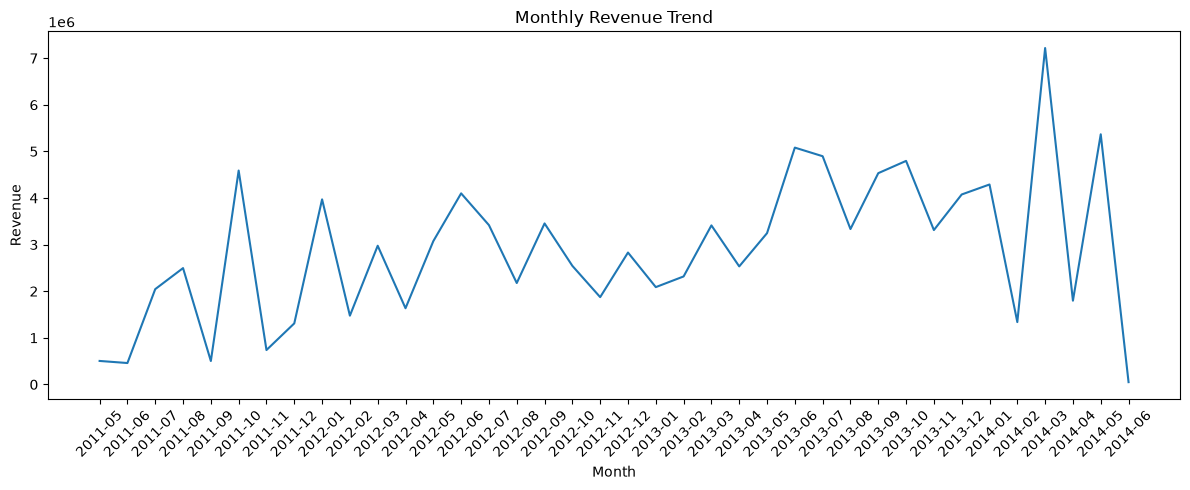

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_performance_df["OrderMonth"].astype(str),
    monthly_performance_df["Revenue"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [72]:
monthly_performance_df["IsFinalPeriod"] = (
    monthly_performance_df["OrderMonth"]
    == monthly_performance_df["OrderMonth"].max()
)

In [73]:
print(
    monthly_performance_df[
        ["OrderMonth", "Revenue", "IsFinalPeriod"]
    ].tail()
)

   OrderMonth       Revenue  IsFinalPeriod
33    2014-02  1.337725e+06          False
34    2014-03  7.217531e+06          False
35    2014-04  1.797174e+06          False
36    2014-05  5.366675e+06          False
37    2014-06  4.900584e+04           True


In [74]:
def classify_monthly_performance(row):
    insights = []

    revenue_change = row["RevenueChangePct"]
    margin_change = row["MarginChangePts"]
    margin = row["GrossMarginPct"]
    is_final_period = row["IsFinalPeriod"]

    if revenue_change >= 30:
        insights.append("Strong revenue growth")

    elif revenue_change <= -30:
        insights.append("Significant revenue decline")

    if margin_change <= -5:
        insights.append("Margin deterioration")

    elif margin_change >= 5:
        insights.append("Margin improvement")

    if margin < 0:
        insights.append("Negative gross margin")

    if is_final_period:
        insights.append("Final reporting period")

    return insights

In [75]:
monthly_performance_df["Insights"] = (
    monthly_performance_df.apply(
        classify_monthly_performance,
        axis=1
    )
)

In [76]:
print(
    monthly_performance_df[
        [
            "OrderMonth",
            "Revenue",
            "RevenueChangePct",
            "GrossMarginPct",
            "MarginChangePts",
            "IsFinalPeriod",
            "Insights"
        ]
    ].tail()
)

   OrderMonth       Revenue  RevenueChangePct  GrossMarginPct  \
33    2014-02  1.337725e+06        -68.816275       41.341079   
34    2014-03  7.217531e+06        439.537715        9.361444   
35    2014-04  1.797174e+06        -75.099880       41.536891   
36    2014-05  5.366675e+06        198.617452       14.766565   
37    2014-06  4.900584e+04        -99.086849       55.842327   

    MarginChangePts  IsFinalPeriod  \
33        26.247925          False   
34       -31.979634          False   
35        32.175447          False   
36       -26.770326          False   
37        41.075762           True   

                                             Insights  
33  [Significant revenue decline, Margin improvement]  
34      [Strong revenue growth, Margin deterioration]  
35  [Significant revenue decline, Margin improvement]  
36      [Strong revenue growth, Margin deterioration]  
37  [Significant revenue decline, Margin improveme...  


In [78]:
def generate_monthly_commentary(row):
    month = row["OrderMonth"]
    revenue = row["Revenue"]
    revenue_change = row["RevenueChangePct"]
    margin = row["GrossMarginPct"]
    margin_change = row["MarginChangePts"]
    is_final_period = row["IsFinalPeriod"]

    commentary = (
        f"{month}: Revenue was ${revenue:,.0f}, "
        f"changing {revenue_change:+.1f}% from the previous month. "
        f"Gross margin was {margin:.1f}%, "
        f"changing {margin_change:+.1f} percentage points."
    )

    if is_final_period:
        commentary += (
            " This is the final reporting period, "
            "so the month-over-month revenue movement "
            "should be interpreted with caution."
        )

    return commentary

In [79]:
june_2014 = monthly_performance_df.iloc[-1]

print(generate_monthly_commentary(june_2014))

2014-06: Revenue was $49,006, changing -99.1% from the previous month. Gross margin was 55.8%, changing +41.1 percentage points. This is the final reporting period, so the month-over-month revenue movement should be interpreted with caution.


In [80]:
category_performance_df = (
    commercial_reporting_df
    .groupby("ProductCategory")
    .agg(
        Revenue=("Revenue", "sum"),
        Cost=("Cost", "sum"),
        GrossProfit=("GrossProfit", "sum"),
        UnitsSold=("OrderQty", "sum"),
        SalesLines=("SalesOrderDetailID", "count"),
        Products=("ProductID", "nunique")
    )
    .reset_index()
)

category_performance_df["GrossMarginPct"] = (
    category_performance_df["GrossProfit"]
    / category_performance_df["Revenue"]
) * 100

category_performance_df = category_performance_df.sort_values(
    "Revenue",
    ascending=False
)

print(category_performance_df.to_string(index=False))

ProductCategory      Revenue         Cost  GrossProfit  UnitsSold  SalesLines  Products  GrossMarginPct
          Bikes 9.465117e+07 8.413189e+07 1.051928e+07      90268       40031        97       11.113740
     Components 1.180259e+07 1.076848e+07 1.034118e+06      49044       18698       111        8.761783
       Clothing 2.120543e+06 1.750636e+06 3.699062e+05      73670       21394        34       17.443943
    Accessories 1.272073e+06 6.376010e+05 6.344718e+05      61932       41194        24       49.877004


In [81]:
product_performance_df = (
    commercial_reporting_df
    .groupby(["ProductID", "ProductName"])
    .agg(
        Revenue=("Revenue", "sum"),
        Cost=("Cost", "sum"),
        GrossProfit=("GrossProfit", "sum"),
        UnitsSold=("OrderQty", "sum"),
        SalesLines=("SalesOrderDetailID", "count")
    )
    .reset_index()
)

product_performance_df["GrossMarginPct"] = (
    product_performance_df["GrossProfit"]
    / product_performance_df["Revenue"]
) * 100

product_performance_df = product_performance_df.sort_values(
    "Revenue",
    ascending=False
)

print(
    product_performance_df.head(15).to_string(index=False)
)

 ProductID             ProductName      Revenue         Cost   GrossProfit  UnitsSold  SalesLines  GrossMarginPct
       782  Mountain-200 Black, 38 4.400593e+06 3527770.6769 872822.123500       2977        1252       19.834194
       783  Mountain-200 Black, 42 4.009495e+06 3145694.0071 863800.754741       2664        1177       21.543880
       779 Mountain-200 Silver, 38 3.693678e+06 2864545.6146 829132.410672       2394        1094       22.447339
       780 Mountain-200 Silver, 42 3.438479e+06 2662489.7854 775989.075023       2234        1040       22.567801
       781 Mountain-200 Silver, 46 3.434257e+06 2640299.6888 793957.253128       2216        1054       23.118749
       784  Mountain-200 Black, 46 3.309673e+06 2501584.8772 808088.339708       2111        1059       24.415955
       793      Road-250 Black, 44 2.516857e+06 2347774.8361 169082.478818       1642         705        6.718000
       794      Road-250 Black, 48 2.347656e+06 2145414.6357 202241.317754       1498   

In [83]:
customer_performance_df = (
    commercial_reporting_df
    .groupby(
        ["CustomerID", "AccountNumber", "FirstName", "LastName"]
    )
    .agg(
        Revenue=("Revenue", "sum"),
        Cost=("Cost", "sum"),
        GrossProfit=("GrossProfit", "sum"),
        UnitsSold=("OrderQty", "sum"),
        SalesLines=("SalesOrderDetailID", "count"),
        ProductsPurchased=("ProductID", "nunique")
    )
    .reset_index()
)

customer_performance_df["GrossMarginPct"] = (
    customer_performance_df["GrossProfit"]
    / customer_performance_df["Revenue"]
) * 100

customer_performance_df = customer_performance_df.sort_values(
    "Revenue",
    ascending=False
)

print(
    customer_performance_df.head(15).to_string(index=False)
)

 CustomerID AccountNumber FirstName    LastName       Revenue        Cost   GrossProfit  UnitsSold  SalesLines  ProductsPurchased  GrossMarginPct
      29818    AW00029818     Roger       Harui 877107.192221 814369.5564  62737.635821       1558         298                 81        7.152790
      29715    AW00029715    Andrew       Dixon 853849.179524 873278.1599 -19428.980376       1322         366                 82       -2.275458
      29722    AW00029722    Reuben        D'sa 841908.770707 839778.5200   2130.250707       2737         530                118        0.253026
      30117    AW00030117    Robert       Vessa 816755.576276 835395.0988 -18639.522524       1736         436                 93       -2.282142
      29614    AW00029614      Ryan    Calafato 799277.895062 822271.3133 -22993.418238       1931         451                 91       -2.876774
      29639    AW00029639    Joseph Castellucio 787773.043768 801555.5543 -13782.510532       1708         429              

In [84]:
seller_performance_df = (
    commercial_reporting_df
    .groupby(
        [
            "SalesPersonID",
            "SalesPersonFirstName",
            "SalesPersonLastName"
        ]
    )
    .agg(
        Revenue=("Revenue", "sum"),
        Cost=("Cost", "sum"),
        GrossProfit=("GrossProfit", "sum"),
        UnitsSold=("OrderQty", "sum"),
        SalesLines=("SalesOrderDetailID", "count"),
        Customers=("CustomerID", "nunique")
    )
    .reset_index()
)

seller_performance_df["GrossMarginPct"] = (
    seller_performance_df["GrossProfit"]
    / seller_performance_df["Revenue"]
) * 100

seller_performance_df = seller_performance_df.sort_values(
    "Revenue",
    ascending=False
)

print(
    seller_performance_df.to_string(index=False)
)

 SalesPersonID SalesPersonFirstName SalesPersonLastName      Revenue         Cost    GrossProfit  UnitsSold  SalesLines  Customers  GrossMarginPct
         276.0                Linda            Mitchell 1.036701e+07 1.019499e+07  172016.112733      27229        7107         69        1.659265
         277.0              Jillian              Carson 1.006580e+07 9.901268e+06  164535.612242      27051        7825        121        1.634600
         275.0              Michael              Blythe 9.293903e+06 9.171834e+06  122069.418201      23058        7069        118        1.313435
         289.0                  Jae                 Pak 8.503339e+06 8.269611e+06  233727.937686      26231        6738         62        2.748661
         279.0                 Tsvi              Reiter 7.171013e+06 7.060057e+06  110955.358141      16431        5417         74        1.547276
         281.0                  Shu                 Ito 6.427006e+06 6.589409e+06 -162403.175811      15397        454

In [85]:
report_data = {
    "executive": executive_kpis,
    "monthly": monthly_performance_df.copy(),
    "category": category_performance_df.copy(),
    "product": product_performance_df.copy(),
    "customer": customer_performance_df.copy(),
    "seller": seller_performance_df.copy()
}

print("Report data package created.")
print(f"Sections: {len(report_data)}")
print("Available sections:", list(report_data.keys()))

Report data package created.
Sections: 6
Available sections: ['executive', 'monthly', 'category', 'product', 'customer', 'seller']


In [86]:
from pathlib import Path
from openpyxl import Workbook

report_output_dir = Path("reports")
report_output_dir.mkdir(exist_ok=True)

report_path = (
    report_output_dir
    / "adventureworks_commercial_performance_report.xlsx"
)

workbook = Workbook()

print("Report folder:", report_output_dir)
print("Report path:", report_path)
print("Workbook created.")

Report folder: reports
Report path: reports\adventureworks_commercial_performance_report.xlsx
Workbook created.


In [87]:
executive_sheet = workbook.create_sheet("Executive Summary")

print("Worksheet created:", executive_sheet.title)

Worksheet created: Executive Summary


In [88]:
executive_sheet["A1"] = "AUTOMATED COMMERCIAL PERFORMANCE REPORT"

print(executive_sheet["A1"].value)

AUTOMATED COMMERCIAL PERFORMANCE REPORT


In [89]:
executive_sheet["A3"] = "Reporting Period"

executive_sheet["B3"] = (
    f"{executive_kpis['report_start_date'].strftime('%Y-%m-%d')}"
    f" to "
    f"{executive_kpis['report_end_date'].strftime('%Y-%m-%d')}"
)

print(executive_sheet["A3"].value)
print(executive_sheet["B3"].value)

Reporting Period
2011-05-31 to 2014-06-30


In [90]:
executive_sheet["A5"] = "Revenue"
executive_sheet["B5"] = executive_kpis["revenue"]

executive_sheet["A6"] = "Cost"
executive_sheet["B6"] = executive_kpis["cost"]

executive_sheet["A7"] = "Gross Profit"
executive_sheet["B7"] = executive_kpis["gross_profit"]

executive_sheet["A8"] = "Gross Margin %"
executive_sheet["B8"] = executive_kpis["gross_margin_pct"]

executive_sheet["A9"] = "Sales Lines"
executive_sheet["B9"] = executive_kpis["sales_lines"]

executive_sheet["A10"] = "Units Sold"
executive_sheet["B10"] = executive_kpis["units_sold"]

executive_sheet["A11"] = "Customers"
executive_sheet["B11"] = executive_kpis["customers"]

executive_sheet["A12"] = "Products"
executive_sheet["B12"] = executive_kpis["products"]

print("Executive KPI block created.")

Executive KPI block created.


In [91]:
executive_sheet["B5"].number_format = '$#,##0.00'
executive_sheet["B6"].number_format = '$#,##0.00'
executive_sheet["B7"].number_format = '$#,##0.00'
executive_sheet["B8"].number_format = '0.00%'

executive_sheet["B9"].number_format = '#,##0'
executive_sheet["B10"].number_format = '#,##0'
executive_sheet["B11"].number_format = '#,##0'
executive_sheet["B12"].number_format = '#,##0'

print("KPI number formats applied.")

KPI number formats applied.


In [92]:
executive_sheet["B8"] = executive_kpis["gross_margin_pct"] / 100
executive_sheet["B8"].number_format = '0.00%'

print("Gross Margin formatted as percentage.")

Gross Margin formatted as percentage.


In [93]:
monthly_report_df = monthly_performance_df[
    [
        "OrderMonth",
        "Revenue",
        "Cost",
        "GrossProfit",
        "GrossMarginPct",
        "SalesLines"
    ]
].copy()

print(monthly_report_df.head().to_string(index=False))

OrderMonth      Revenue         Cost   GrossProfit  GrossMarginPct  SalesLines
   2011-05 5.038059e+05  480616.0464  23189.870500        4.602937         357
   2011-06 4.589108e+05  274099.7172 184811.107600       40.271682         141
   2011-07 2.044600e+06 1771778.7539 272821.249438       13.343502         941
   2011-08 2.495817e+06 2217734.0941 278082.639346       11.141949        1242
   2011-09 5.020738e+05  300539.8445 201534.001300       40.140311         157


In [94]:
monthly_sheet = workbook.create_sheet("Monthly Performance")

monthly_sheet["A1"] = "MONTHLY COMMERCIAL PERFORMANCE"

print("Worksheet created:", monthly_sheet.title)

Worksheet created: Monthly Performance


In [95]:
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter


def write_dataframe_to_sheet(
    workbook,
    sheet_name,
    dataframe,
    title=None
):
    """
    Write a pandas DataFrame into an Excel worksheet.
    """

    worksheet = workbook.create_sheet(sheet_name)

    current_row = 1

    if title:
        worksheet.cell(
            row=current_row,
            column=1,
            value=title
        )

        worksheet.cell(
            row=current_row,
            column=1
        ).font = Font(
            bold=True,
            size=14
        )

        current_row += 2

    for column_index, column_name in enumerate(
        dataframe.columns,
        start=1
    ):
        cell = worksheet.cell(
            row=current_row,
            column=column_index,
            value=column_name
        )

        cell.font = Font(bold=True)
        cell.alignment = Alignment(
            horizontal="center"
        )

    current_row += 1

    for row in dataframe.itertuples(
        index=False,
        name=None
    ):
        for column_index, value in enumerate(
            row,
            start=1
        ):
            worksheet.cell(
                row=current_row,
                column=column_index,
                value=value
            )

        current_row += 1

    for column_index in range(
        1,
        len(dataframe.columns) + 1
    ):
        column_letter = get_column_letter(
            column_index
        )

        worksheet.column_dimensions[
            column_letter
        ].width = 18

    worksheet.freeze_panes = (
        f"A{3 if title else 2}"
    )

    return worksheet

In [97]:
monthly_report_df["OrderMonth"] = (
    monthly_report_df["OrderMonth"]
    .astype(str)
)

In [98]:
print(monthly_report_df["OrderMonth"].head())
print()
print("Data type:", monthly_report_df["OrderMonth"].dtype)

0    2011-05
1    2011-06
2    2011-07
3    2011-08
4    2011-09
Name: OrderMonth, dtype: str

Data type: str


In [99]:
if "Monthly Test" in workbook.sheetnames:
    del workbook["Monthly Test"]

print("Current worksheets:")
print(workbook.sheetnames)

Current worksheets:
['Sheet', 'Executive Summary', 'Monthly Performance']


In [100]:
if "Sheet" in workbook.sheetnames:
    del workbook["Sheet"]

print("Current worksheets:")
print(workbook.sheetnames)

Current worksheets:
['Executive Summary', 'Monthly Performance']


In [101]:
test_sheet = write_dataframe_to_sheet(
    workbook,
    "Monthly Test",
    monthly_report_df,
    "Monthly Performance Test"
)

print("Test worksheet created:", test_sheet.title)

Test worksheet created: Monthly Test


In [102]:
print("A1:", test_sheet["A1"].value)
print("A3:", test_sheet["A3"].value)
print("B3:", test_sheet["B3"].value)
print("C3:", test_sheet["C3"].value)
print("D3:", test_sheet["D3"].value)
print("E3:", test_sheet["E3"].value)
print("F3:", test_sheet["F3"].value)

print("A4:", test_sheet["A4"].value)
print("B4:", test_sheet["B4"].value)

A1: Monthly Performance Test
A3: OrderMonth
B3: Revenue
C3: Cost
D3: GrossProfit
E3: GrossMarginPct
F3: SalesLines
A4: 2011-05
B4: 503805.9169


In [103]:
if "Monthly Test" in workbook.sheetnames:
    del workbook["Monthly Test"]

print("Current worksheets:")
print(workbook.sheetnames)

Current worksheets:
['Executive Summary', 'Monthly Performance']


In [104]:
def write_dataframe_to_sheet(
    workbook,
    sheet_name,
    dataframe,
    title=None
):
    """
    Write a pandas DataFrame into an Excel worksheet.

    If the worksheet already exists, use it.
    Otherwise, create it.
    """

    if sheet_name in workbook.sheetnames:
        worksheet = workbook[sheet_name]
    else:
        worksheet = workbook.create_sheet(sheet_name)

    # Clear existing worksheet contents
    for row in worksheet.iter_rows():
        for cell in row:
            cell.value = None

    current_row = 1

    if title:
        worksheet.cell(
            row=current_row,
            column=1,
            value=title
        )

        worksheet.cell(
            row=current_row,
            column=1
        ).font = Font(
            bold=True,
            size=14
        )

        current_row += 2

    # Write column headers
    for column_index, column_name in enumerate(
        dataframe.columns,
        start=1
    ):
        cell = worksheet.cell(
            row=current_row,
            column=column_index,
            value=column_name
        )

        cell.font = Font(bold=True)
        cell.alignment = Alignment(
            horizontal="center"
        )

    current_row += 1

    # Write dataframe rows
    for row in dataframe.itertuples(
        index=False,
        name=None
    ):
        for column_index, value in enumerate(
            row,
            start=1
        ):
            worksheet.cell(
                row=current_row,
                column=column_index,
                value=value
            )

        current_row += 1

    # Set basic column widths
    for column_index in range(
        1,
        len(dataframe.columns) + 1
    ):
        column_letter = get_column_letter(
            column_index
        )

        worksheet.column_dimensions[
            column_letter
        ].width = 18

    # Freeze the header row
    worksheet.freeze_panes = (
        f"A{3 if title else 2}"
    )

    return worksheet

In [105]:
monthly_sheet = write_dataframe_to_sheet(
    workbook,
    "Monthly Performance",
    monthly_report_df,
    "Monthly Commercial Performance"
)

print("Monthly worksheet populated.")
print("Worksheet:", monthly_sheet.title)
print("Rows:", monthly_sheet.max_row)
print("Columns:", monthly_sheet.max_column)

Monthly worksheet populated.
Worksheet: Monthly Performance
Rows: 41
Columns: 6


In [106]:
print("A1:", monthly_sheet["A1"].value)
print("A3:", monthly_sheet["A3"].value)
print("B3:", monthly_sheet["B3"].value)
print("A4:", monthly_sheet["A4"].value)
print("B4:", monthly_sheet["B4"].value)
print("A41:", monthly_sheet["A41"].value)
print("B41:", monthly_sheet["B41"].value)

A1: Monthly Commercial Performance
A3: OrderMonth
B3: Revenue
A4: 2011-05
B4: 503805.9169
A41: 2014-06
B41: 49005.840000000004


In [107]:
category_report_df = category_performance_df[
    [
        "ProductCategory",
        "Revenue",
        "Cost",
        "GrossProfit",
        "GrossMarginPct",
        "UnitsSold",
        "SalesLines",
        "Products"
    ]
].copy()

print(category_report_df.to_string(index=False))

ProductCategory      Revenue         Cost  GrossProfit  GrossMarginPct  UnitsSold  SalesLines  Products
          Bikes 9.465117e+07 8.413189e+07 1.051928e+07       11.113740      90268       40031        97
     Components 1.180259e+07 1.076848e+07 1.034118e+06        8.761783      49044       18698       111
       Clothing 2.120543e+06 1.750636e+06 3.699062e+05       17.443943      73670       21394        34
    Accessories 1.272073e+06 6.376010e+05 6.344718e+05       49.877004      61932       41194        24


In [108]:
category_sheet = write_dataframe_to_sheet(
    workbook,
    "Category Performance",
    category_report_df,
    "Category Performance"
)

print("Category worksheet created.")
print("Rows:", category_sheet.max_row)
print("Columns:", category_sheet.max_column)

Category worksheet created.
Rows: 7
Columns: 8


In [109]:
product_report_df = product_performance_df[
    [
        "ProductID",
        "ProductName",
        "Revenue",
        "Cost",
        "GrossProfit",
        "GrossMarginPct",
        "UnitsSold",
        "SalesLines"
    ]
].head(15).copy()

print(product_report_df.to_string(index=False))

 ProductID             ProductName      Revenue         Cost   GrossProfit  GrossMarginPct  UnitsSold  SalesLines
       782  Mountain-200 Black, 38 4.400593e+06 3527770.6769 872822.123500       19.834194       2977        1252
       783  Mountain-200 Black, 42 4.009495e+06 3145694.0071 863800.754741       21.543880       2664        1177
       779 Mountain-200 Silver, 38 3.693678e+06 2864545.6146 829132.410672       22.447339       2394        1094
       780 Mountain-200 Silver, 42 3.438479e+06 2662489.7854 775989.075023       22.567801       2234        1040
       781 Mountain-200 Silver, 46 3.434257e+06 2640299.6888 793957.253128       23.118749       2216        1054
       784  Mountain-200 Black, 46 3.309673e+06 2501584.8772 808088.339708       24.415955       2111        1059
       793      Road-250 Black, 44 2.516857e+06 2347774.8361 169082.478818        6.718000       1642         705
       794      Road-250 Black, 48 2.347656e+06 2145414.6357 202241.317754        8.6146

In [110]:
product_sheet = write_dataframe_to_sheet(
    workbook,
    "Product Performance",
    product_report_df,
    "Top 15 Products by Revenue"
)

print("Product worksheet created.")
print("Rows:", product_sheet.max_row)
print("Columns:", product_sheet.max_column)

Product worksheet created.
Rows: 18
Columns: 8


In [111]:
customer_report_df = customer_performance_df[
    [
        "CustomerID",
        "AccountNumber",
        "FirstName",
        "LastName",
        "Revenue",
        "Cost",
        "GrossProfit",
        "GrossMarginPct",
        "UnitsSold",
        "SalesLines",
        "ProductsPurchased"
    ]
].head(15).copy()

print(customer_report_df.to_string(index=False))

 CustomerID AccountNumber FirstName    LastName       Revenue        Cost   GrossProfit  GrossMarginPct  UnitsSold  SalesLines  ProductsPurchased
      29818    AW00029818     Roger       Harui 877107.192221 814369.5564  62737.635821        7.152790       1558         298                 81
      29715    AW00029715    Andrew       Dixon 853849.179524 873278.1599 -19428.980376       -2.275458       1322         366                 82
      29722    AW00029722    Reuben        D'sa 841908.770707 839778.5200   2130.250707        0.253026       2737         530                118
      30117    AW00030117    Robert       Vessa 816755.576276 835395.0988 -18639.522524       -2.282142       1736         436                 93
      29614    AW00029614      Ryan    Calafato 799277.895062 822271.3133 -22993.418238       -2.876774       1931         451                 91
      29639    AW00029639    Joseph Castellucio 787773.043768 801555.5543 -13782.510532       -1.749553       1708         4

In [112]:
customer_sheet = write_dataframe_to_sheet(
    workbook,
    "Customer Performance",
    customer_report_df,
    "Top 15 Customers by Revenue"
)

print("Customer worksheet created.")
print("Rows:", customer_sheet.max_row)
print("Columns:", customer_sheet.max_column)

Customer worksheet created.
Rows: 18
Columns: 11


In [113]:
seller_report_df = seller_performance_df[
    [
        "SalesPersonID",
        "SalesPersonFirstName",
        "SalesPersonLastName",
        "Revenue",
        "Cost",
        "GrossProfit",
        "GrossMarginPct",
        "UnitsSold",
        "SalesLines",
        "Customers"
    ]
].copy()

print(seller_report_df.to_string(index=False))

 SalesPersonID SalesPersonFirstName SalesPersonLastName      Revenue         Cost    GrossProfit  GrossMarginPct  UnitsSold  SalesLines  Customers
         276.0                Linda            Mitchell 1.036701e+07 1.019499e+07  172016.112733        1.659265      27229        7107         69
         277.0              Jillian              Carson 1.006580e+07 9.901268e+06  164535.612242        1.634600      27051        7825        121
         275.0              Michael              Blythe 9.293903e+06 9.171834e+06  122069.418201        1.313435      23058        7069        118
         289.0                  Jae                 Pak 8.503339e+06 8.269611e+06  233727.937686        2.748661      26231        6738         62
         279.0                 Tsvi              Reiter 7.171013e+06 7.060057e+06  110955.358141        1.547276      16431        5417         74
         281.0                  Shu                 Ito 6.427006e+06 6.589409e+06 -162403.175811       -2.526887      

In [114]:
seller_sheet = write_dataframe_to_sheet(
    workbook,
    "Seller Performance",
    seller_report_df,
    "Seller Performance"
)

print("Seller worksheet created.")
print("Rows:", seller_sheet.max_row)
print("Columns:", seller_sheet.max_column)

Seller worksheet created.
Rows: 20
Columns: 10


In [115]:
workbook.save(report_path)

print("Report saved successfully.")
print("File:", report_path)

Report saved successfully.
File: reports\adventureworks_commercial_performance_report.xlsx


In [116]:
from openpyxl import load_workbook

saved_workbook = load_workbook(report_path)

print("Saved workbook reopened successfully.")
print("Worksheets:", saved_workbook.sheetnames)

Saved workbook reopened successfully.
Worksheets: ['Executive Summary', 'Monthly Performance', 'Category Performance', 'Product Performance', 'Customer Performance', 'Seller Performance']


In [117]:
checks = {
    "Executive Title": saved_workbook["Executive Summary"]["A1"].value,
    "Reporting Period": saved_workbook["Executive Summary"]["B3"].value,
    "Revenue": saved_workbook["Executive Summary"]["B5"].value,
    "Gross Profit": saved_workbook["Executive Summary"]["B7"].value,
    "Monthly First Period": saved_workbook["Monthly Performance"]["A4"].value,
    "Monthly First Revenue": saved_workbook["Monthly Performance"]["B4"].value,
    "Category First Category": saved_workbook["Category Performance"]["A4"].value,
    "Product First Product": saved_workbook["Product Performance"]["B4"].value,
    "Customer First Customer": saved_workbook["Customer Performance"]["C4"].value,
    "Seller First Seller": saved_workbook["Seller Performance"]["B4"].value,
}

for check, value in checks.items():
    print(f"{check}: {value}")

Executive Title: AUTOMATED COMMERCIAL PERFORMANCE REPORT
Reporting Period: 2011-05-31 to 2014-06-30
Revenue: 109846381.399888
Gross Profit: 12557780.599088
Monthly First Period: 2011-05
Monthly First Revenue: 503805.9169
Category First Category: Bikes
Product First Product: Mountain-200 Black, 38
Customer First Customer: Roger
Seller First Seller: Linda


In [118]:
from openpyxl.styles import Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

executive_sheet = saved_workbook["Executive Summary"]

# ---------------------------------------------------------
# 1. Title
# ---------------------------------------------------------

executive_sheet["A1"].font = Font(
    bold=True,
    size=18
)

executive_sheet["A1"].alignment = Alignment(
    horizontal="left"
)

# ---------------------------------------------------------
# 2. Reporting period
# ---------------------------------------------------------

executive_sheet["A3"].font = Font(
    bold=True,
    size=11
)

executive_sheet["B3"].font = Font(
    size=11
)

# ---------------------------------------------------------
# 3. KPI labels
# ---------------------------------------------------------

for row in range(5, 13):
    executive_sheet.cell(
        row=row,
        column=1
    ).font = Font(
        bold=True
    )

# ---------------------------------------------------------
# 4. KPI number formats
# ---------------------------------------------------------

for cell in ["B5", "B6", "B7"]:
    executive_sheet[cell].number_format = '$#,##0.00'

executive_sheet["B8"] = (
    executive_kpis["gross_margin_pct"] / 100
)

executive_sheet["B8"].number_format = '0.00%'

for cell in ["B9", "B10", "B11", "B12"]:
    executive_sheet[cell].number_format = '#,##0'

# ---------------------------------------------------------
# 5. Borders around KPI block
# ---------------------------------------------------------

thin_border = Border(
    left=Side(style="thin"),
    right=Side(style="thin"),
    top=Side(style="thin"),
    bottom=Side(style="thin")
)

for row in range(5, 13):
    for column in range(1, 3):
        executive_sheet.cell(
            row=row,
            column=column
        ).border = thin_border

# ---------------------------------------------------------
# 6. Alignment
# ---------------------------------------------------------

for row in range(5, 13):
    executive_sheet.cell(
        row=row,
        column=2
    ).alignment = Alignment(
        horizontal="right"
    )

# ---------------------------------------------------------
# 7. Column widths
# ---------------------------------------------------------

executive_sheet.column_dimensions["A"].width = 24
executive_sheet.column_dimensions["B"].width = 24

# ---------------------------------------------------------
# 8. Freeze panes
# ---------------------------------------------------------

executive_sheet.freeze_panes = "A5"

print("Executive Summary formatting applied.")

Executive Summary formatting applied.


In [119]:
saved_workbook.save(report_path)

print("Formatted report saved successfully.")
print("File:", report_path)

Formatted report saved successfully.
File: reports\adventureworks_commercial_performance_report.xlsx


In [120]:
saved_workbook = load_workbook(report_path)

executive_sheet = saved_workbook["Executive Summary"]

print("Formatted workbook reopened successfully.")
print("Title:", executive_sheet["A1"].value)
print("Reporting Period:", executive_sheet["B3"].value)
print("Revenue:", executive_sheet["B5"].value)
print("Gross Margin:", executive_sheet["B8"].value)
print("Freeze Panes:", executive_sheet.freeze_panes)

Formatted workbook reopened successfully.
Title: AUTOMATED COMMERCIAL PERFORMANCE REPORT
Reporting Period: 2011-05-31 to 2014-06-30
Revenue: 109846381.399888
Gross Margin: 0.1143212952402345
Freeze Panes: A5


In [121]:
from openpyxl.styles import Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

thin_border = Border(
    left=Side(style="thin"),
    right=Side(style="thin"),
    top=Side(style="thin"),
    bottom=Side(style="thin")
)


def format_detail_sheet(
    worksheet,
    currency_columns=None,
    percentage_columns=None,
    integer_columns=None
):
    """
    Apply consistent presentation formatting to a report worksheet.
    """

    currency_columns = currency_columns or []
    percentage_columns = percentage_columns or []
    integer_columns = integer_columns or []

    # -----------------------------------------------------
    # Title
    # -----------------------------------------------------

    worksheet["A1"].font = Font(
        bold=True,
        size=14
    )

    # -----------------------------------------------------
    # Header row
    # -----------------------------------------------------

    header_row = 3

    for cell in worksheet[header_row]:
        if cell.value is not None:
            cell.font = Font(
                bold=True
            )
            cell.alignment = Alignment(
                horizontal="center"
            )
            cell.border = thin_border

    # -----------------------------------------------------
    # Data cells
    # -----------------------------------------------------

    for row in worksheet.iter_rows(
        min_row=header_row + 1
    ):
        for cell in row:
            if cell.value is not None:
                cell.border = thin_border

    # -----------------------------------------------------
    # Number formats
    # -----------------------------------------------------

    header_map = {
        cell.value: cell.column
        for cell in worksheet[header_row]
        if cell.value is not None
    }

    for column_name in currency_columns:
        if column_name in header_map:
            column_index = header_map[column_name]

            for row in range(
                header_row + 1,
                worksheet.max_row + 1
            ):
                worksheet.cell(
                    row=row,
                    column=column_index
                ).number_format = '$#,##0.00'

    for column_name in percentage_columns:
        if column_name in header_map:
            column_index = header_map[column_name]

            for row in range(
                header_row + 1,
                worksheet.max_row + 1
            ):
                cell = worksheet.cell(
                    row=row,
                    column=column_index
                )

                # Convert percentage values such as
                # 11.43 into Excel's 0.1143 representation.
                if isinstance(cell.value, (int, float)):
                    cell.value = cell.value / 100

                cell.number_format = '0.00%'

    for column_name in integer_columns:
        if column_name in header_map:
            column_index = header_map[column_name]

            for row in range(
                header_row + 1,
                worksheet.max_row + 1
            ):
                worksheet.cell(
                    row=row,
                    column=column_index
                ).number_format = '#,##0'

    # -----------------------------------------------------
    # Column widths
    # -----------------------------------------------------

    for column_index in range(
        1,
        worksheet.max_column + 1
    ):
        column_letter = get_column_letter(
            column_index
        )

        max_length = 0

        for row in worksheet.iter_rows(
            min_col=column_index,
            max_col=column_index
        ):
            for cell in row:
                if cell.value is not None:
                    max_length = max(
                        max_length,
                        len(str(cell.value))
                    )

        worksheet.column_dimensions[
            column_letter
        ].width = min(
            max(max_length + 2, 12),
            30
        )

    # -----------------------------------------------------
    # Freeze and filter
    # -----------------------------------------------------

    worksheet.freeze_panes = "A4"

    worksheet.auto_filter.ref = (
        f"A3:{get_column_letter(worksheet.max_column)}"
        f"{worksheet.max_row}"
    )

    return worksheet

In [122]:
format_detail_sheet(
    saved_workbook["Monthly Performance"],
    currency_columns=[
        "Revenue",
        "Cost",
        "GrossProfit"
    ],
    percentage_columns=[
        "GrossMarginPct"
    ],
    integer_columns=[
        "SalesLines"
    ]
)

format_detail_sheet(
    saved_workbook["Category Performance"],
    currency_columns=[
        "Revenue",
        "Cost",
        "GrossProfit"
    ],
    percentage_columns=[
        "GrossMarginPct"
    ],
    integer_columns=[
        "UnitsSold",
        "SalesLines",
        "Products"
    ]
)

format_detail_sheet(
    saved_workbook["Product Performance"],
    currency_columns=[
        "Revenue",
        "Cost",
        "GrossProfit"
    ],
    percentage_columns=[
        "GrossMarginPct"
    ],
    integer_columns=[
        "ProductID",
        "UnitsSold",
        "SalesLines"
    ]
)

format_detail_sheet(
    saved_workbook["Customer Performance"],
    currency_columns=[
        "Revenue",
        "Cost",
        "GrossProfit"
    ],
    percentage_columns=[
        "GrossMarginPct"
    ],
    integer_columns=[
        "CustomerID",
        "UnitsSold",
        "SalesLines",
        "ProductsPurchased"
    ]
)

format_detail_sheet(
    saved_workbook["Seller Performance"],
    currency_columns=[
        "Revenue",
        "Cost",
        "GrossProfit"
    ],
    percentage_columns=[
        "GrossMarginPct"
    ],
    integer_columns=[
        "SalesPersonID",
        "UnitsSold",
        "SalesLines",
        "Customers"
    ]
)

print("All five detail worksheets formatted successfully.")

All five detail worksheets formatted successfully.


In [123]:
monthly_sheet = saved_workbook["Monthly Performance"]
seller_sheet = saved_workbook["Seller Performance"]

print("MONTHLY PERFORMANCE")
print("Title:", monthly_sheet["A1"].value)
print("Header:", monthly_sheet["A3"].value)
print("First period:", monthly_sheet["A4"].value)
print("Revenue:", monthly_sheet["B4"].value)
print("Revenue format:", monthly_sheet["B4"].number_format)
print("Margin:", monthly_sheet["E4"].value)
print("Margin format:", monthly_sheet["E4"].number_format)
print("Freeze panes:", monthly_sheet.freeze_panes)
print("Filter:", monthly_sheet.auto_filter.ref)

print()
print("SELLER PERFORMANCE")
print("Title:", seller_sheet["A1"].value)
print("Header:", seller_sheet["A3"].value)
print("First seller:", seller_sheet["B4"].value)
print("Revenue:", seller_sheet["D4"].value)
print("Revenue format:", seller_sheet["D4"].number_format)
print("Margin:", seller_sheet["G4"].value)
print("Margin format:", seller_sheet["G4"].number_format)
print("Freeze panes:", seller_sheet.freeze_panes)
print("Filter:", seller_sheet.auto_filter.ref)

MONTHLY PERFORMANCE
Title: Monthly Commercial Performance
Header: OrderMonth
First period: 2011-05
Revenue: 503805.9169
Revenue format: $#,##0.00
Margin: 0.04602937306233135
Margin format: 0.00%
Freeze panes: A4
Filter: A3:F41

SELLER PERFORMANCE
Title: Seller Performance
Header: SalesPersonID
First seller: Linda
Revenue: 10367007.426033
Revenue format: $#,##0.00
Margin: 0.01659264874268768
Margin format: 0.00%
Freeze panes: A4
Filter: A3:J20


In [124]:
saved_workbook.save(report_path)

print("Formatted workbook saved successfully.")
print("File:", report_path)

Formatted workbook saved successfully.
File: reports\adventureworks_commercial_performance_report.xlsx


In [ ]:
# ============================================================
# EXECUTIVE TREND CHART
# ============================================================

# ------------------------------------------------------------
# Import Excel chart tools
# ------------------------------------------------------------

from openpyxl.chart import LineChart, Reference


# ------------------------------------------------------------
# Create the chart
# ------------------------------------------------------------

monthly_sheet = saved_workbook["Monthly Performance"]
executive_sheet = saved_workbook["Executive Summary"]

trend_chart = LineChart()

trend_chart.title = "Monthly Revenue & Gross Profit Trend"
trend_chart.style = 2
trend_chart.height = 8
trend_chart.width = 18


# ------------------------------------------------------------
# Define the data ranges
# ------------------------------------------------------------

revenue_data = Reference(
    monthly_sheet,
    min_col=2,
    min_row=3,
    max_row=41
)

gross_profit_data = Reference(
    monthly_sheet,
    min_col=4,
    min_row=3,
    max_row=41
)

month_labels = Reference(
    monthly_sheet,
    min_col=1,
    min_row=4,
    max_row=41
)


# ------------------------------------------------------------
# Add Revenue and Gross Profit to the chart
# ------------------------------------------------------------

trend_chart.add_data(
    revenue_data,
    titles_from_data=True
)

trend_chart.add_data(
    gross_profit_data,
    titles_from_data=True
)

trend_chart.set_categories(
    month_labels
)


# ------------------------------------------------------------
# Place the chart on Executive Summary
# ------------------------------------------------------------

executive_sheet.add_chart(
    trend_chart,
    "D2"
)


print("Executive trend chart created successfully.")
print("Chart location: Executive Summary!D2")
print("Data source: Monthly Performance")
print("Series: Revenue, Gross Profit")

Executive trend chart created successfully.
Chart location: Executive Summary!D2
Data source: Monthly Performance
Series: Revenue, Gross Profit


In [126]:
# ============================================================
# SAVE AND VALIDATE EXECUTIVE TREND CHART
# ============================================================

# Save the workbook
saved_workbook.save(report_path)

print("Workbook saved with Executive Trend Chart.")
print("File:", report_path)


# Reopen the saved workbook
saved_workbook = load_workbook(report_path)

executive_sheet = saved_workbook["Executive Summary"]

print()
print("Saved workbook reopened successfully.")
print("Worksheets:", saved_workbook.sheetnames)
print("Charts on Executive Summary:", len(executive_sheet._charts))
print("Chart title:", executive_sheet._charts[0].title.tx.rich.p[0].r[0].t)

Workbook saved with Executive Trend Chart.
File: reports\adventureworks_commercial_performance_report.xlsx

Saved workbook reopened successfully.
Worksheets: ['Executive Summary', 'Monthly Performance', 'Category Performance', 'Product Performance', 'Customer Performance', 'Seller Performance']
Charts on Executive Summary: 1
Chart title: Monthly Revenue & Gross Profit Trend


In [127]:
# ============================================================
# FINAL REPORT VALIDATION
# ============================================================

expected_sheets = [
    "Executive Summary",
    "Monthly Performance",
    "Category Performance",
    "Product Performance",
    "Customer Performance",
    "Seller Performance"
]

actual_sheets = saved_workbook.sheetnames

# ------------------------------------------------------------
# 1. Worksheet validation
# ------------------------------------------------------------

sheets_pass = actual_sheets == expected_sheets

print("Worksheet validation:", "PASS" if sheets_pass else "FAIL")


# ------------------------------------------------------------
# 2. Executive Summary validation
# ------------------------------------------------------------

executive_sheet = saved_workbook["Executive Summary"]

executive_pass = (
    executive_sheet["A1"].value
    == "AUTOMATED COMMERCIAL PERFORMANCE REPORT"
    and executive_sheet["B5"].value is not None
    and executive_sheet["B7"].value is not None
    and len(executive_sheet._charts) == 1
)

print(
    "Executive Summary validation:",
    "PASS" if executive_pass else "FAIL"
)


# ------------------------------------------------------------
# 3. Detail worksheet validation
# ------------------------------------------------------------

detail_sheets = [
    "Monthly Performance",
    "Category Performance",
    "Product Performance",
    "Customer Performance",
    "Seller Performance"
]

detail_results = {}

for sheet_name in detail_sheets:
    worksheet = saved_workbook[sheet_name]

    has_title = worksheet["A1"].value is not None
    has_header = worksheet["A3"].value is not None
    has_data = worksheet.max_row > 3
    has_filter = worksheet.auto_filter.ref is not None
    has_freeze = worksheet.freeze_panes == "A4"

    detail_results[sheet_name] = (
        has_title
        and has_header
        and has_data
        and has_filter
        and has_freeze
    )

    print(
        f"{sheet_name}:",
        "PASS" if detail_results[sheet_name] else "FAIL"
    )


# ------------------------------------------------------------
# 4. Overall validation
# ------------------------------------------------------------

all_details_pass = all(detail_results.values())

overall_pass = (
    sheets_pass
    and executive_pass
    and all_details_pass
)

print()
print(
    "FINAL REPORT VALIDATION:",
    "PASS" if overall_pass else "FAIL"
)

Worksheet validation: PASS
Executive Summary validation: PASS
Monthly Performance: PASS
Category Performance: PASS
Product Performance: PASS
Customer Performance: PASS
Seller Performance: PASS

FINAL REPORT VALIDATION: PASS
